### Imports ###

In [1]:
import pyspiel 
import numpy as np
from open_spiel.python.algorithms import cfr 
from open_spiel.python import rl_environment
from open_spiel.python import rl_tools 
from open_spiel.python.algorithms import random_agent
from open_spiel.python import policy as policy_lib
from open_spiel.python.algorithms import exploitability
from open_spiel.python.algorithms import evaluate_bots
from open_spiel.python.algorithms import cfr_br
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 
import collections 
import re 

In [2]:
# GLOBAL VARIABLE TO BE REUSED THROUGHOUT NOTEBOOK
game = pyspiel.load_game("leduc_poker")

### Combine reweighting and utility change to create a single CFR algorithm ###

In [2]:
def value_func(val, alpha=0.88, beta=0.88, lambdaa=2.25):
    if val >= 0: 
        return val ** alpha 
    return -lambdaa * ((-val) ** beta)

def tk_weight(p, gamma):
    """TK probability weighting function."""
    return p**gamma / (p**gamma + (1 - p)**gamma)**(1 / gamma)

def cpt_weights_wb(probs, utilities, player, gamma_gain=0.69, gamma_loss=0.61):
    """
    CPT decision weights following Tversky-Kahneman (1992):
    - Sort all outcomes worst-to-best in a single pass
    - Build cumulative probabilities from the bottom up
    - Switch between gamma+ and gamma- depending on sign of outcome
    - Decision weight = w(F_i) - w(F_{i-1})
    - Sum to 1 is guaranteed by the telescoping construction
    """
    u = utilities[:, player]
    n = len(probs)
    weights = np.zeros(n)

    # Single pass: sort all outcomes worst-to-best
    sorted_order = np.argsort(u)

    cum = 0.0
    prev_w = 0.0
    for idx in sorted_order:
        cum += probs[idx]
        gamma = gamma_gain if u[idx] >= 0 else gamma_loss
        w_cum = tk_weight(cum, gamma)
        weights[idx] = w_cum - prev_w
        prev_w = w_cum

    # Renormalization as numerical safety net only
    total = weights.sum()
    if total > 1e-12:
        weights /= total
    else:
        weights = probs.copy()

    return weights

def new_reach(so_far, player, action_prob):
  """Returns new reach probabilities."""
  new = np.array(so_far)
  new[player] *= action_prob
  return new

def calc_cfr(state, reach):
    """Updates regrets; returns utility for all players."""
    if state.is_terminal():
        utilities = np.array([value_func(u) for u in state.returns()])
        return utilities
    elif state.is_chance_node():
        return sum(
            prob * calc_cfr(state.child(action), new_reach(reach, -1, prob))
            for action, prob in state.chance_outcomes()
        )
    else:
        player = state.current_player()
        index = policy.state_index(state)
        legal = state.legal_actions()

        # --- Compute utilities after each action (recurse) ---
        utility = np.zeros((game.num_distinct_actions(), game.num_players()))
        for action in legal:
            prob = curr_policy[index][action]
            utility[action] = calc_cfr(
                state.child(action), new_reach(reach, player, prob)
            )

        # --- CPT-distorted probabilities for value computation ---
        # Extract probs and utilities only over legal actions
        legal_arr = np.array(legal)
        legal_probs = curr_policy[index][legal_arr]         # raw policy probs
        cpt_probs = cpt_weights_wb(legal_probs, utility[legal_arr], player)

        # --- Counterfactual weight (reach of all OTHER players) ---
        cfr_prob = np.prod(reach[:player]) * np.prod(reach[player + 1:])

        # --- Node value uses CPT-distorted probabilities ---
        # value[p] = sum_a  cpt_prob[a] * utility[a][p]
        value = np.zeros(game.num_players())
        for i, action in enumerate(legal):
            value += cpt_probs[i] * utility[action]

        # --- Regret update still uses raw utility vs CPT-weighted value ---
        for i, action in enumerate(legal):
            regrets[index][action] += cfr_prob * (
                utility[action][player] - value[player]
            )

        return value

In [7]:
game = pyspiel.load_game('leduc_poker')
policy = policy_lib.TabularPolicy(game)
initial_state = game.new_initial_state()
curr_policy = policy.action_probability_array.copy()
regrets = np.zeros_like(policy.action_probability_array)
eval_steps = []
eval_nash_conv = []
for step in range(4097):
  # Compute regrets
  calc_cfr(initial_state, np.ones(1 + game.num_players()))

  # Find the new regret-matching policy
  floored_regrets = np.maximum(regrets, 1e-16)
  sum_floored_regrets = np.sum(floored_regrets, axis=1, keepdims=True)
  curr_policy = floored_regrets / sum_floored_regrets

  # Update the average policy
  lr = 1 / (1 + step)
  policy.action_probability_array *= (1 - lr)
  policy.action_probability_array += curr_policy * lr

  # Evaluate the average policy
  if step & (step-1) == 0:
    nc = exploitability.nash_conv(game, policy)
    eval_steps.append(step)
    eval_nash_conv.append(nc)
    print(f'Nash conv after step {step} is {nc}')

with open('cpt_cfr_policy.pkl', 'wb') as f:
    pickle.dump(policy, f)

Nash conv after step 0 is 3.273988829431203


/var/folders/56/1yfkkw_j243c09c394_fxr4c0000gn/T/ipykernel_4419/2957401884.py:8: RuntimeWarning: invalid value encountered in scalar power
  return p**gamma / (p**gamma + (1 - p)**gamma)**(1 / gamma)


Nash conv after step 1 is 2.9459179979092105
Nash conv after step 2 is 2.2937639343878087
Nash conv after step 4 is 1.7954664311050723
Nash conv after step 8 is 1.5991060090821303
Nash conv after step 16 is 1.6610150261591041
Nash conv after step 32 is 1.7397621166631732
Nash conv after step 64 is 1.5951748160405346
Nash conv after step 128 is 1.16513309495629
Nash conv after step 256 is 1.2214834179910055
Nash conv after step 512 is 1.5379372221338383
Nash conv after step 1024 is 1.4483876067864005
Nash conv after step 2048 is 1.3198270490610906
Nash conv after step 4096 is 1.4034978031411192


### Computation strategy CFR (CFR +) ###

In [4]:
# create standard cfr policy 
state = game.new_initial_state()
solver = cfr.CFRSolver(game)

NUM_ITERATIONS = 2000
LOG_EVERY = 50
exploitabilities = []

for i in range(1, NUM_ITERATIONS+1):
    solver.evaluate_and_update_policy()

    if i % LOG_EVERY == 0:
        avg_policy = solver.average_policy()
        expl = exploitability.nash_conv(game, avg_policy)
        print(f"{i:>10}  {expl:>16.6f}")
        exploitabilities.append(expl)

average_policy = solver.average_policy()
final_expl = exploitability.nash_conv(game, average_policy)
print(f"\nFinal exploitability after {NUM_ITERATIONS} iterations: {final_expl:.6f}")
with open('standard_cfr_policy.pkl', 'wb') as f:
    pickle.dump(average_policy, f)

        50          0.378167
       100          0.191433
       150          0.125318
       200          0.107677
       250          0.080938
       300          0.071048
       350          0.061189
       400          0.052872
       450          0.049439
       500          0.043014
       550          0.041250
       600          0.039551
       650          0.035089
       700          0.032639
       750          0.030102
       800          0.028723
       850          0.027625
       900          0.028119
       950          0.026073
      1000          0.023636
      1050          0.023650
      1100          0.023105
      1150          0.021994
      1200          0.019832
      1250          0.019451
      1300          0.019560
      1350          0.018835
      1400          0.017724
      1450          0.018827
      1500          0.017138
      1550          0.014822
      1600          0.016057
      1650          0.015516
      1700          0.016502
      1750    

In [3]:
# load policy for standard cfr, so don't have to run it again 
with open("standard_cfr_policy.pkl", "rb") as f:
    standard_cfr_policy = pickle.load(f)

In [4]:
# load policy for modified cfr, so don't have to run it again 
with open('cpt_cfr_policy.pkl', 'rb') as f:
    policy = pickle.load(f)

### Simulation CFR-CPT against standard-CFR

In [9]:
class SimpleBot:

    def __init__(self, policy, player_id): 
        self.policy = policy 
        self.player_id = player_id

    def step(self, state):
        """
        Given the state of the game, return an action to take, 
        selecting at random from the policy distribution.
        """
        action_probs = self.policy.action_probabilities(state)
        actions, probs = zip(*action_probs.items())
        return random.choices(actions, probs)[0]
    
def simulate_game(n=500):
    cpt_returns = 0.0
    gto_returns = 0.0

    for _ in range(n):
        # Randomly assign positions
        if random.random() < 0.5:
            bots = [SimpleBot(average_policy, 0), SimpleBot(policy, 1)]
            cpt_player = 1
        else:
            bots = [SimpleBot(policy, 0), SimpleBot(average_policy, 1)]
            cpt_player = 0

        state = game.new_initial_state()
        while not state.is_terminal():
            if state.is_chance_node():
                outcomes, probs = zip(*state.chance_outcomes())
                action = random.choices(outcomes, weights=probs)[0]
            else:
                bot = bots[state.current_player()]
                action = bot.step(state)
            state.apply_action(action)

        r = state.returns()
        cpt_returns += r[cpt_player]
        gto_returns += r[1 - cpt_player]

    print(f"After simulating {n} games:")
    print(f"CPT policy average return: {cpt_returns/n:.4f}")
    print(f"GTO policy average return: {gto_returns/n:.4f}")
    return [cpt_returns/n, gto_returns/n]

game_returns = []
for _ in range(100):
    avg_returns_sim = simulate_game(10000)
    game_returns.append(avg_returns_sim)

game_returns = np.array(game_returns)
print(f"\nAverage returns over 100 simulations:")
print(f"CPT policy average return: {np.mean(game_returns[:, 0]):.4f}")
print(f"GTO policy average return: {np.mean(game_returns[:, 1]):.4f}")



After simulating 10000 games:
CPT policy average return: 0.0268
GTO policy average return: -0.0268
After simulating 10000 games:
CPT policy average return: -0.0554
GTO policy average return: 0.0554
After simulating 10000 games:
CPT policy average return: 0.0064
GTO policy average return: -0.0064
After simulating 10000 games:
CPT policy average return: 0.0039
GTO policy average return: -0.0039
After simulating 10000 games:
CPT policy average return: 0.0192
GTO policy average return: -0.0192
After simulating 10000 games:
CPT policy average return: -0.0109
GTO policy average return: 0.0109
After simulating 10000 games:
CPT policy average return: -0.0583
GTO policy average return: 0.0583
After simulating 10000 games:
CPT policy average return: -0.0140
GTO policy average return: 0.0140
After simulating 10000 games:
CPT policy average return: -0.0205
GTO policy average return: 0.0205
After simulating 10000 games:
CPT policy average return: 0.0079
GTO policy average return: -0.0079
After simu

### Test Exploitability CFR-CPT and standard CFR ###

In [10]:
expl = exploitability.exploitability(game, policy)
print(f"Exploitability: {expl:.4f}")

# Or compute best response value directly
br_info = exploitability.best_response(game, policy, 1)
print(f"Best response value for player 1 against your policy: {br_info['best_response_value']:.4f}")



Exploitability: 0.7017
Best response value for player 1 against your policy: 0.6827


In [11]:
expl_cfr = exploitability.exploitability(game, average_policy)
print(f"Exploitability of CFR average policy: {expl_cfr:.4f}")

br_info_cfr = exploitability.best_response(game, average_policy, 1)
print(f"Best response value for player 1 against CFR average policy: {br_info_cfr['best_response_value']:.4f}")

Exploitability of CFR average policy: 0.0068
Best response value for player 1 against CFR average policy: 0.0942


### Explore-then-Commit Algorithm ### 

## AGENTS ##

In [6]:
class Bot: 
    def __init__(self, policy):
        self.policy = policy
        self.player_id = None # to be set at the start of each hand, depending on position

    def step(self, state):
        action_probs = self.policy.action_probabilities(state)
        actions, probs = zip(*action_probs.items())
        return random.choices(actions, probs)[0]

In [5]:
class ETCAgent: 
    def __init__(self, exploration_policy, m): 
        self.exploration_policy = exploration_policy
        self.m                  = m
        self.player_id          = None
        self.info_sets          = {}
        self.opponent_obs       = collections.defaultdict(lambda: {0: 0, 1: 0, 2: 0})
        self.info_state_visits  = collections.defaultdict(int)
        self.hands_played       = 0
        self.br_actions         = {}


    def _public_key(self, state):
        """Public history: skip the initial private card deals (one per player)."""
        return tuple(state.history()[game.num_players():])

    def observe_info_set(self, state, action):
        """Record opponent action, keyed by public history (no private cards)."""
        if self.br_actions:
            return
        key = self._public_key(state)
        self.opponent_obs[key][action] += 1
        self.info_state_visits[key] += 1

    def step(self, state):
        if self.hands_played < self.m:
            return self.explore(state)
        else:
            return self.commit(state)

    def explore(self, state):
        action_probs = self.exploration_policy.action_probabilities(state)
        actions, probs = zip(*action_probs.items())
        return random.choices(actions, probs)[0]

    def commit(self, state):
        key = state.information_state_string(self.player_id)
        if key not in self.br_actions:
            return self.explore(state)
        return self.br_actions[key]

    def estimate_opponent_strategy(self):
        """Normalize observed counts into probabilities."""
        for key, action_counts in self.opponent_obs.items():
            visits = self.info_state_visits[key]
            self.info_sets[key] = {action: count / visits for action, count in action_counts.items()}

    def end_hand(self):
        self.hands_played += 1
        if self.hands_played == self.m:
            self.estimate_opponent_strategy()
            self.build_best_response()

    def build_best_response(self):
        """Traverse full game tree once, store best action for every info set."""
        self.br_actions = {}
        self._compute_br(game.new_initial_state())
        print(f"[ETC] Best response built over {len(self.br_actions)} info sets.")

    def _compute_br(self, state):
        """Recursively compute best response. Returns EV for self.player_id."""
        if state.is_terminal():
            return state.returns()[self.player_id]

        if state.is_chance_node():
            ev = 0.0
            for action, prob in state.chance_outcomes():
                ev += prob * self._compute_br(state.child(action))
            return ev

        legal_actions = state.legal_actions()

        if state.current_player() == self.player_id:
            key = state.information_state_string(self.player_id)
            best_action, best_ev = None, -float('inf')
            for action in legal_actions:
                ev = self._compute_br(state.child(action))
                if ev > best_ev:
                    best_ev, best_action = ev, action
            self.br_actions[key] = best_action
            return best_ev

        else:
            key = self._public_key(state)
            belief = self.info_sets.get(key, {a: 1/len(legal_actions) for a in legal_actions})
            ev = 0.0
            for action in legal_actions:
                p = belief.get(action, 0.0)
                if p > 0:
                    ev += p * self._compute_br(state.child(action))
            return ev

In [7]:
class ETCAgentV2(ETCAgent): 
    """
    Like ETCAgent, but groups opponent observations by rank-only public history.
    In Leduc poker suits are irrelevant, so J1/J2, Q1/Q2, K1/K2 are merged
    into a single bucket — fewer info sets to estimate, better sample efficiency.
    """

    def _public_key(self, state):
        """
        Public history with the community card normalized to rank only.
        Cards are encoded 0-5: J1=0,J2=1,Q1=2,Q2=3,K1=4,K2=5
        so card // 2 gives rank (J=0, Q=1, K=2).
        Player actions (fold=0, call=1, raise=2) are kept as-is.
        We replay the history to tell chance entries (community card) apart
        from player action entries.
        """
        h = state.history()
        # Advance a fresh state past the private card deals
        s = game.new_initial_state()
        for action in h[:game.num_players()]:
            s.apply_action(action)
        # Build rank-normalized public key
        norm = []
        for action in h[game.num_players():]:
            if s.is_chance_node():
                norm.append(action // 2)  # community card → rank only
            else:
                norm.append(action)       # player action, unchanged
            s.apply_action(action)
        return tuple(norm)
    

In [8]:
class ETCAgentV3(ETCAgentV2):
    """
    Like ETCAgentV2, but also normalizes the agent's own private card to rank only.
    Since the agent plays the same regardless of suit (J1==J2, Q1==Q2, K1==K2),
    info sets that differ only in the suit of the hole card are merged.
    Own-node key: (hole_card_rank,) + rank-normalized public history.
    """

    def _own_key(self, state):
        """Own info key: hole card rank + rank-normalized public history."""
        our_rank = state.history()[self.player_id] // 2  # J=0, Q=1, K=2
        return (our_rank,) + self._public_key(state)

    def commit(self, state):
        key = self._own_key(state)
        if key not in self.br_actions:
            return self.explore(state)
        return self.br_actions[key]

    def _compute_br(self, state):
        if state.is_terminal():
            return state.returns()[self.player_id]

        if state.is_chance_node():
            ev = 0.0
            for action, prob in state.chance_outcomes():
                ev += prob * self._compute_br(state.child(action))
            return ev

        legal_actions = state.legal_actions()

        if state.current_player() == self.player_id:
            key = self._own_key(state)
            best_action, best_ev = None, -float('inf')
            for action in legal_actions:
                ev = self._compute_br(state.child(action))
                if ev > best_ev:
                    best_ev, best_action = ev, action
            self.br_actions[key] = best_action
            return best_ev

        else:
            key = self._public_key(state)
            belief = self.info_sets.get(key, {a: 1/len(legal_actions) for a in legal_actions})
            ev = 0.0
            for action in legal_actions:
                p = belief.get(action, 0.0)
                if p > 0:
                    ev += p * self._compute_br(state.child(action))
            return ev

In [9]:
class ETCAgentV4(ETCAgentV3):
    """
    Like ETCAgentV3, but builds the best response for both player positions.
    The BR traversal runs twice (once as P0, once as P1) so the commit phase
    uses the correct best response regardless of which seat the agent occupies.

    _own_key now prefixes player_id to avoid collisions between P0 and P1
    info sets that share the same rank + public history.
    """

    def _own_key(self, state):
        """Own info key: player_id + hole card rank + rank-normalized public history."""
        our_rank = state.history()[self.player_id] // 2
        return (self.player_id, our_rank) + self._public_key(state)

    def build_best_response(self):
        self.br_actions = {}
        original_player_id = self.player_id
        for pid in range(game.num_players()):
            self.player_id = pid
            self._compute_br(game.new_initial_state())
        self.player_id = original_player_id
        print(f"[ETC] Best response built over {len(self.br_actions)} info sets.")

## SIMULATIONS ##

In [11]:
def simulationETC(Agent, agent_strategy= standard_cfr_policy,opponent_strategy = None, n=10000, n_repetitions=100, m_values = [1000, 2000, 4000, 6000, 8000, 9000, 9500]):
    if opponent_strategy is None:
        with open('cpt_cfr_policy.pkl', 'rb') as f:
            cfr_cpt_policy = pickle.load(f)
        cpt_agent = Bot(cfr_cpt_policy)
    else:
        cpt_agent = Bot(opponent_strategy)
    
    results        = {m: [] for m in m_values}
    commit_results = {m: [] for m in m_values}

    for m in m_values:
        for rep in range(n_repetitions):
            etc_agent = Agent(agent_strategy, m)
            etc_returns    = 0.0
            commit_returns = 0.0

            for i in range(n):
                if random.random() < 0.5:
                    cpt_player = 0
                else:
                    cpt_player = 1
                etc_agent.player_id = 1 - cpt_player

                state = game.new_initial_state()
                while not state.is_terminal():
                    if state.is_chance_node():
                        outcomes, probs = zip(*state.chance_outcomes())
                        action = random.choices(outcomes, weights=probs)[0]
                        state.apply_action(action)
                    elif state.current_player() == cpt_player:
                        action = cpt_agent.step(state)
                        etc_agent.observe_info_set(state, action)
                        state.apply_action(action)
                    else:
                        action = etc_agent.step(state)
                        state.apply_action(action)

                r = state.returns()
                etc_returns += r[1 - cpt_player]

                # hands_played >= m before end_hand means this hand was played in commit mode
                if etc_agent.hands_played >= etc_agent.m:
                    commit_returns += r[1 - cpt_player]

                etc_agent.end_hand()

            results[m].append(etc_returns / n)
            commit_results[m].append(commit_returns / (n - m))

        print(f"m={m} done — avg ETC return: {np.mean(results[m]):.4f}  |  avg commit return: {np.mean(commit_results[m]):.4f}")

    # --- Cumulative return summary ---
    cum_means = [np.mean(results[m]) * n for m in m_values]
    cum_stds  = [np.std(results[m])  * n for m in m_values]
    best_m    = m_values[int(np.argmax(cum_means))]

    print(f"\n{'m':>6}  {'cumulative return':>18}  {'std':>10}")
    print("-" * 40)
    for m, cm, cs in zip(m_values, cum_means, cum_stds):
        marker = "  <-- best" if m == best_m else ""
        print(f"{m:>6}  {cm:>18.2f}  {cs:>10.2f}{marker}")

    # --- Plot: overall vs commit-only average return ---
    means        = [np.mean(results[m])        for m in m_values]
    stds         = [np.std(results[m])         for m in m_values]
    commit_means = [np.mean(commit_results[m]) for m in m_values]
    commit_stds  = [np.std(commit_results[m])  for m in m_values]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(m_values, means, marker='o', linewidth=2, label='overall avg return')
    ax.fill_between(m_values,
                    [mu - s for mu, s in zip(means, stds)],
                    [mu + s for mu, s in zip(means, stds)],
                    alpha=0.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand')
    ax.set_title(f'Overall avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    ax = axes[1]
    ax.plot(m_values, commit_means, marker='o', linewidth=2, color='tab:orange', label='commit-phase avg return')
    ax.fill_between(m_values,
                    [mu - s for mu, s in zip(commit_means, commit_stds)],
                    [mu + s for mu, s in zip(commit_means, commit_stds)],
                    alpha=0.2, color='tab:orange')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand (commit phase only)')
    ax.set_title(f'Commit-phase avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    plt.tight_layout()
    plt.show()

[ETC] Best response built over 343 info sets.
[ETC] Best response built over 413 info sets.
[ETC] Best response built over 358 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 373 info sets.
[ETC] Best response built over 383 info sets.
[ETC] Best response built over 383 info sets.
[ETC] Best response built over 322 info sets.
[ETC] Best response built over 418 info sets.
[ETC] Best response built over 393 info sets.
[ETC] Best response built over 322 info sets.
[ETC] Best response built over 388 info sets.
[ETC] Best response built over 418 info sets.
[ETC] Best response built over 348 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 328 info sets.
[ETC] Best response built over 333 info sets.
[ETC] Best response built over 363 info sets.
[ETC] Best response built over 322 info sets.
[ETC] Best response built over 433 info sets.
[ETC] Best response built over 353

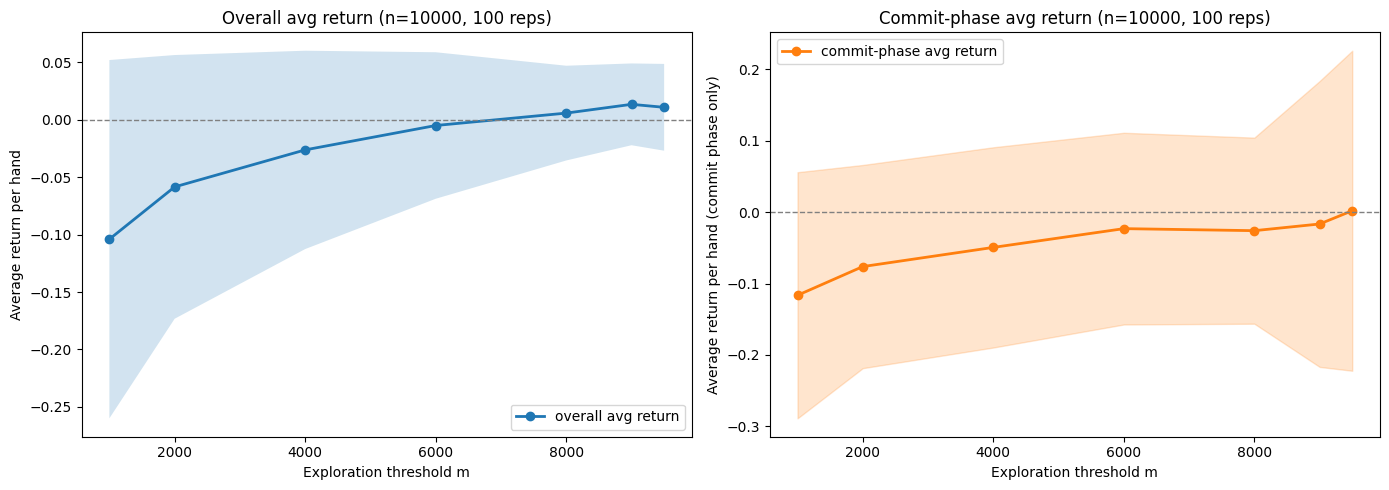

In [65]:
simulationETC(ETCAgent)

[ETC] Best response built over 332 info sets.
[ETC] Best response built over 338 info sets.
[ETC] Best response built over 338 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 428 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 312 info sets.
[ETC] Best response built over 388 info sets.
[ETC] Best response built over 318 info sets.
[ETC] Best response built over 288 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 358 info sets.
[ETC] Best response built over 278 info sets.
[ETC] Best response built over 338 info sets.
[ETC] Best response built over 388 info sets.
[ETC] Best response built over 338 info sets.
[ETC] Best response built over 318 info sets.
[ETC] Best response built over 332 info sets.
[ETC] Best response built over 348 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 302

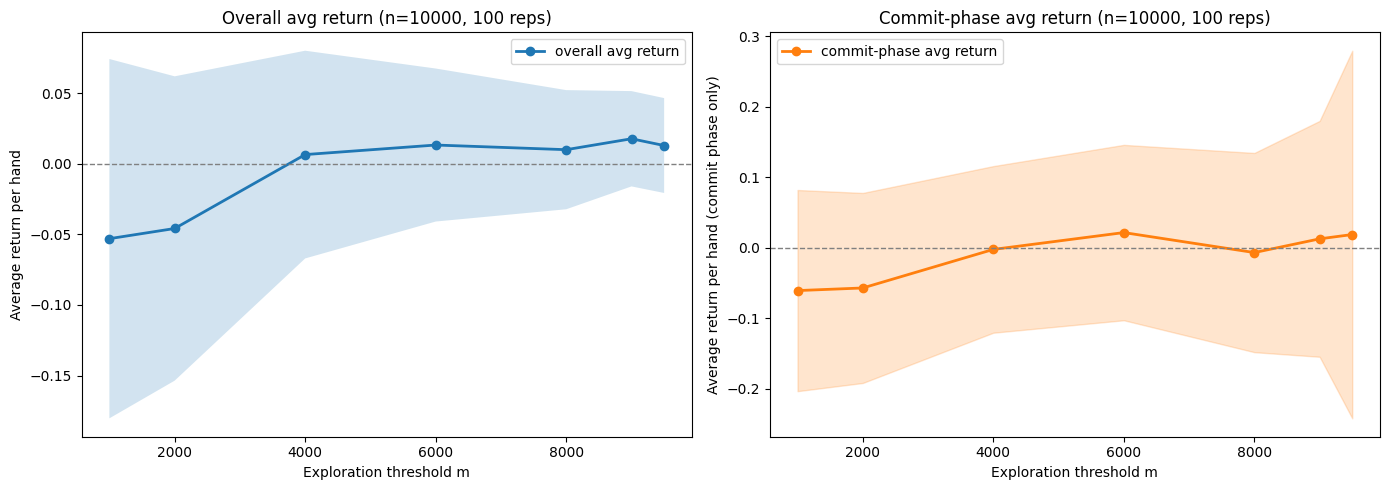

In [42]:
simulationETC(ETCAgentV2)

[ETC] Best response built over 378 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 378 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 368 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 358 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 418 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 288 info sets.
[ETC] Best response built over 318 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 358 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 388 info sets.
[ETC] Best response built over 318

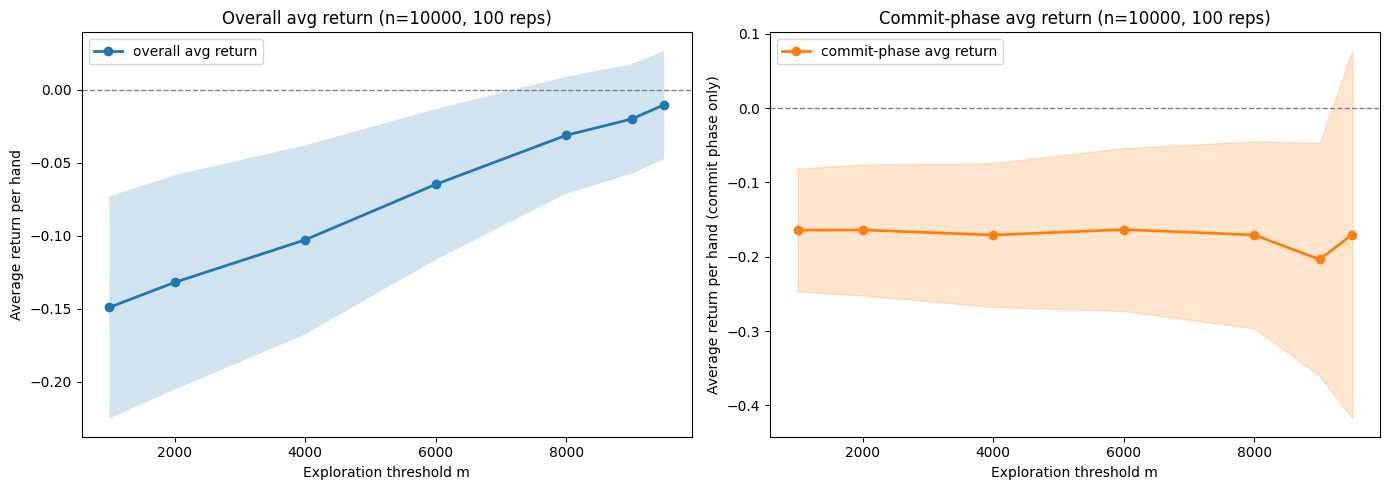

In [46]:
# simulation against opponent playing standard-CFR 
simulationETC(ETCAgentV2, opponent_strategy=average_policy)

In [66]:
def simulationETCFixed(Agent, opponent_strategy = None, position=0, n=10000, n_repetitions=100, m_values = [1000, 2000, 4000, 6000, 8000, 9000, 9500]):
    if opponent_strategy is None:
        with open('cpt_cfr_policy.pkl', 'rb') as f:
            cfr_cpt_policy = pickle.load(f)
        cpt_agent = Bot(cfr_cpt_policy)
    else:
        cpt_agent = Bot(opponent_strategy)
    
    results        = {m: [] for m in m_values}
    commit_results = {m: [] for m in m_values}

    for m in m_values:
        for rep in range(n_repetitions):
            etc_agent = Agent(average_policy, m)
            etc_returns    = 0.0
            commit_returns = 0.0

            for i in range(n):
                etc_agent.player_id = position
                cpt_player = 1 - position

                state = game.new_initial_state()
                while not state.is_terminal():
                    if state.is_chance_node():
                        outcomes, probs = zip(*state.chance_outcomes())
                        action = random.choices(outcomes, weights=probs)[0]
                        state.apply_action(action)
                    elif state.current_player() == cpt_player:
                        action = cpt_agent.step(state)
                        etc_agent.observe_info_set(state, action)
                        state.apply_action(action)
                    else:
                        action = etc_agent.step(state)
                        state.apply_action(action)

                r = state.returns()
                etc_returns += r[1 - cpt_player]

                # hands_played >= m before end_hand means this hand was played in commit mode
                if etc_agent.hands_played >= etc_agent.m:
                    commit_returns += r[1 - cpt_player]

                etc_agent.end_hand()

            results[m].append(etc_returns / n)
            commit_results[m].append(commit_returns / (n - m))

        print(f"m={m} done — avg ETC return: {np.mean(results[m]):.4f}  |  avg commit return: {np.mean(commit_results[m]):.4f}")

    # --- Cumulative return summary ---
    cum_means = [np.mean(results[m]) * n for m in m_values]
    cum_stds  = [np.std(results[m])  * n for m in m_values]
    best_m    = m_values[int(np.argmax(cum_means))]

    print(f"\n{'m':>6}  {'cumulative return':>18}  {'std':>10}")
    print("-" * 40)
    for m, cm, cs in zip(m_values, cum_means, cum_stds):
        marker = "  <-- best" if m == best_m else ""
        print(f"{m:>6}  {cm:>18.2f}  {cs:>10.2f}{marker}")

    # --- Plot: overall vs commit-only average return ---
    means        = [np.mean(results[m])        for m in m_values]
    stds         = [np.std(results[m])         for m in m_values]
    commit_means = [np.mean(commit_results[m]) for m in m_values]
    commit_stds  = [np.std(commit_results[m])  for m in m_values]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(m_values, means, marker='o', linewidth=2, label='overall avg return')
    ax.fill_between(m_values,
                    [mu - s for mu, s in zip(means, stds)],
                    [mu + s for mu, s in zip(means, stds)],
                    alpha=0.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand')
    ax.set_title(f'Overall avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    ax = axes[1]
    ax.plot(m_values, commit_means, marker='o', linewidth=2, color='tab:orange', label='commit-phase avg return')
    ax.fill_between(m_values,
                    [mu - s for mu, s in zip(commit_means, commit_stds)],
                    [mu + s for mu, s in zip(commit_means, commit_stds)],
                    alpha=0.2, color='tab:orange')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand (commit phase only)')
    ax.set_title(f'Commit-phase avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    plt.tight_layout()
    plt.show()

[ETC] Best response built over 378 info sets.
[ETC] Best response built over 338 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 288 info sets.
[ETC] Best response built over 328 info sets.
[ETC] Best response built over 328 info sets.
[ETC] Best response built over 328 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 368 info sets.
[ETC] Best response built over 288 info sets.
[ETC] Best response built over 298 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 328 info sets.
[ETC] Best response built over 308 info sets.
[ETC] Best response built over 328 info sets.
[ETC] Best response built over 318 info sets.
[ETC] Best response built over 318 info sets.
[ETC] Best response built over 268 info sets.
[ETC] Best response built over 318 info sets.
[ETC] Best response built over 288 info sets.
[ETC] Best response built over 328

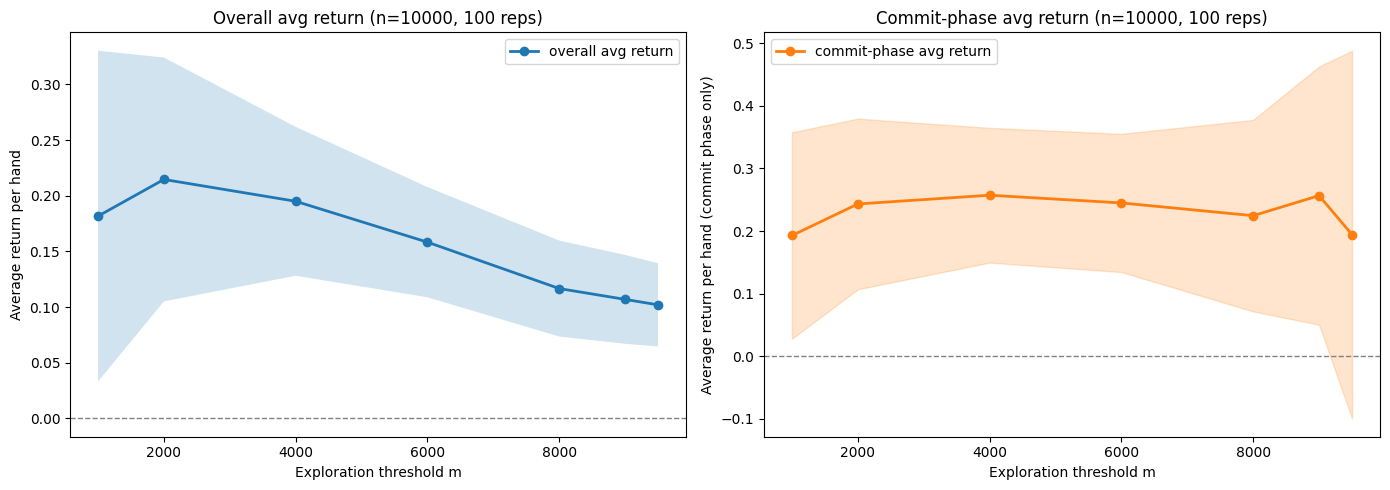

In [ ]:
# without changing position randomly at each hand, here ETCAgent always in position 1 (second to act)
simulationETCFixed(ETCAgentV2, position=1)

[ETC] Best response built over 398 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 388 info sets.
[ETC] Best response built over 428 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 378 info sets.
[ETC] Best response built over 368 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 458 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 418 info sets.
[ETC] Best response built over 388 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 378 info sets.
[ETC] Best response built over 408 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 388 info sets.
[ETC] Best response built over 418 info sets.
[ETC] Best response built over 398 info sets.
[ETC] Best response built over 418

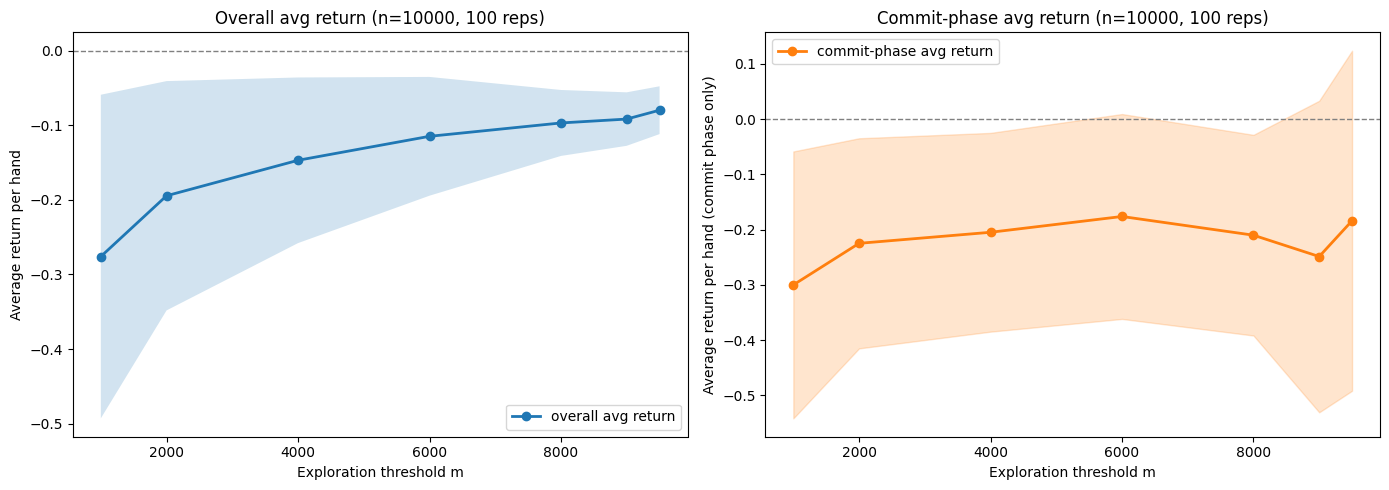

In [53]:
simulationETCFixed(ETCAgentV2, position=0)

[ETC] Best response built over 114 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 66 info sets.
[ETC] Best response built over 87 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 93 info sets.
[ETC] Best response built over 117 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 99 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 111 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 111 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 99 info sets.
[ETC] Best response built over 111 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 120 info sets.
[ETC] Best response built over 105 info sets.
[ETC] Best response built over 96 info 

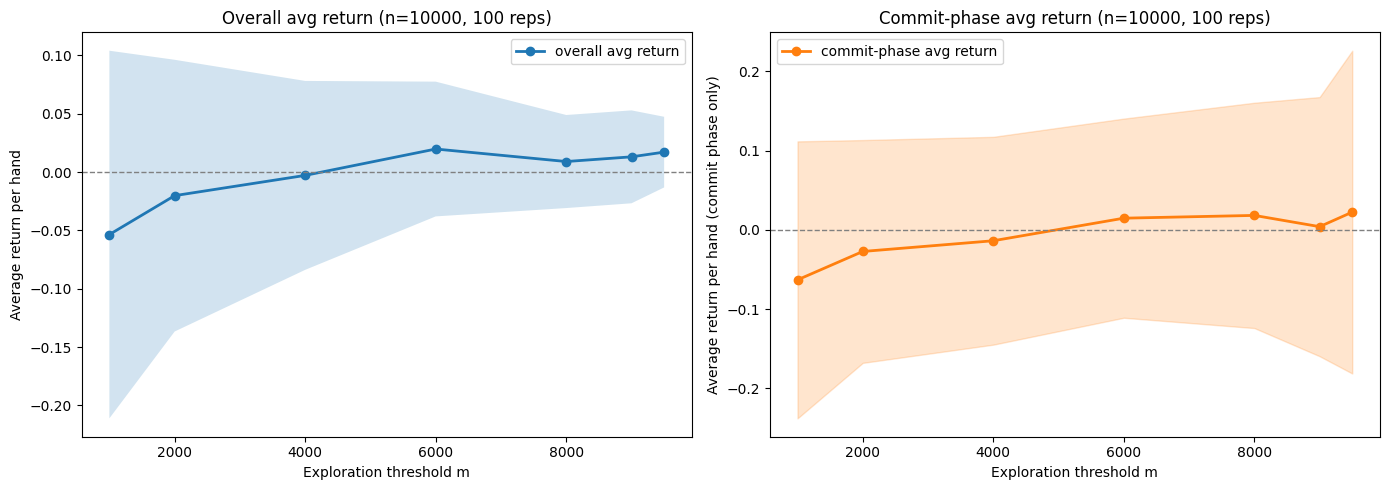

In [12]:
simulationETC(ETCAgentV3)

[ETC] Best response built over 117 info sets.
[ETC] Best response built over 99 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 120 info sets.
[ETC] Best response built over 123 info sets.
[ETC] Best response built over 114 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 120 info sets.
[ETC] Best response built over 141 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 93 info sets.
[ETC] Best response built over 99 info sets.
[ETC] Best response built over 120 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 87 info sets.
[ETC] Best response built over 93 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 120 info

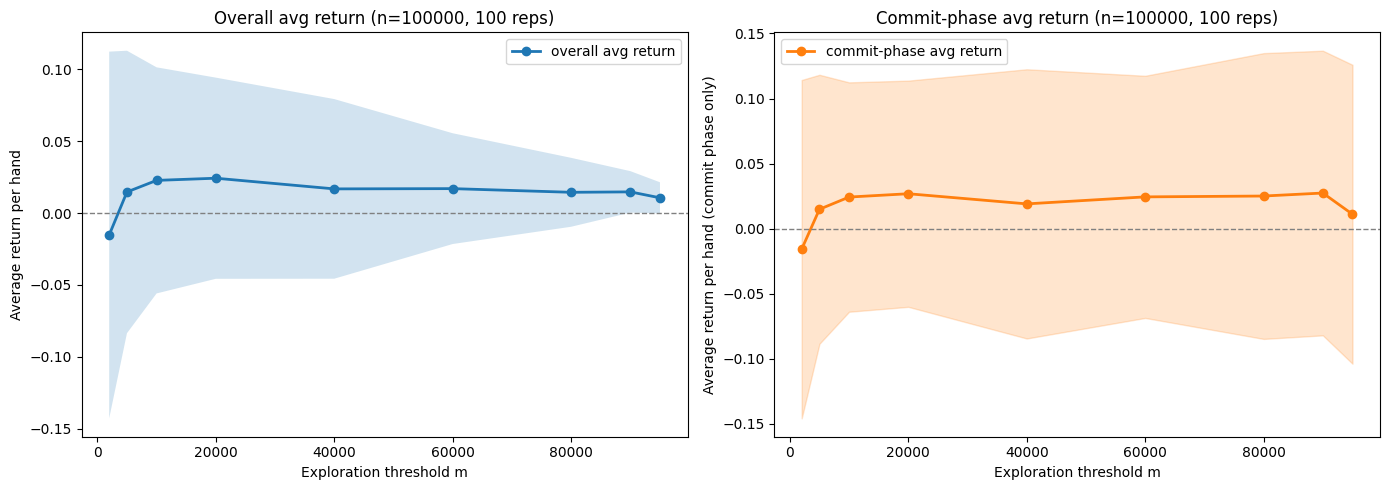

In [13]:
simulationETC(ETCAgentV3, n=100000, m_values=[2000, 5000, 10000, 20000, 40000, 60000, 80000, 90000, 95000])

In [16]:
uniform_strategy = policy_lib.UniformRandomPolicy(game)

[ETC] Best response built over 117 info sets.
[ETC] Best response built over 111 info sets.
[ETC] Best response built over 96 info sets.
[ETC] Best response built over 117 info sets.
[ETC] Best response built over 135 info sets.
[ETC] Best response built over 114 info sets.
[ETC] Best response built over 114 info sets.
[ETC] Best response built over 99 info sets.
[ETC] Best response built over 120 info sets.
[ETC] Best response built over 108 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 132 info sets.
[ETC] Best response built over 105 info sets.
[ETC] Best response built over 108 info sets.
[ETC] Best response built over 99 info sets.
[ETC] Best response built over 141 info sets.
[ETC] Best response built over 135 info sets.
[ETC] Best response built over 105 info sets.
[ETC] Best response built over 105 info sets.
[ETC] Best response built over 135 info sets.
[ETC] Best response built over 111 info sets.
[ETC] Best response built over 138 in

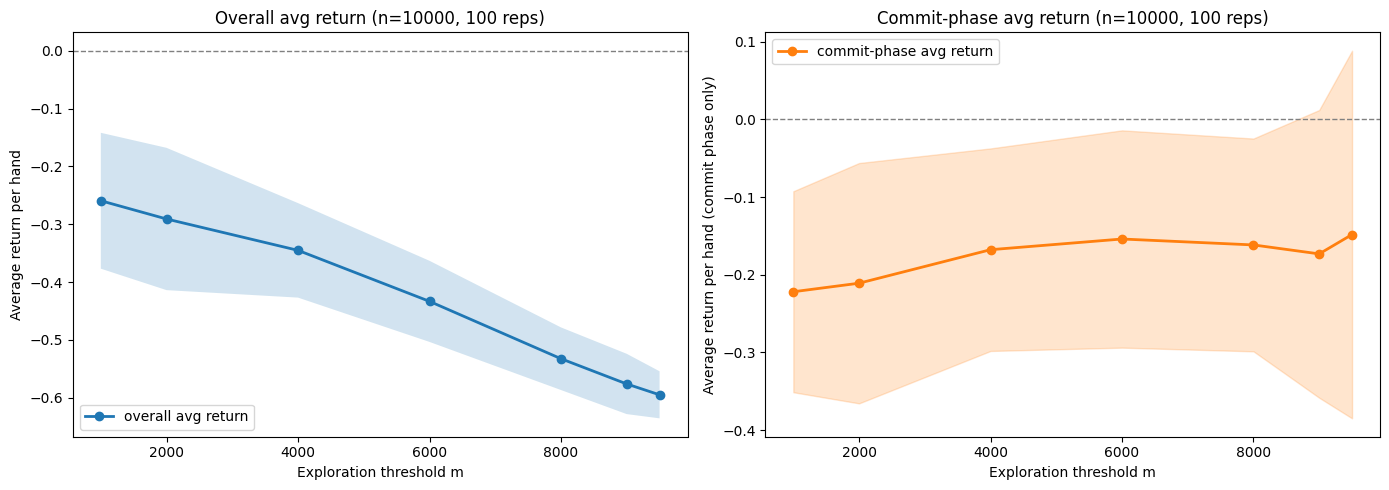

In [15]:
simulationETC(ETCAgentV3, agent_strategy=uniform_strategy)

[ETC] Best response built over 120 info sets.
[ETC] Best response built over 138 info sets.
[ETC] Best response built over 138 info sets.
[ETC] Best response built over 138 info sets.
[ETC] Best response built over 132 info sets.
[ETC] Best response built over 108 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 138 info sets.
[ETC] Best response built over 102 info sets.
[ETC] Best response built over 111 info sets.
[ETC] Best response built over 108 info sets.
[ETC] Best response built over 132 info sets.
[ETC] Best response built over 135 info sets.
[ETC] Best response built over 108 info sets.
[ETC] Best response built over 105 info sets.
[ETC] Best response built over 105 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 120 info sets.
[ETC] Best response built over 108 info sets.
[ETC] Best response built over 138 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 108

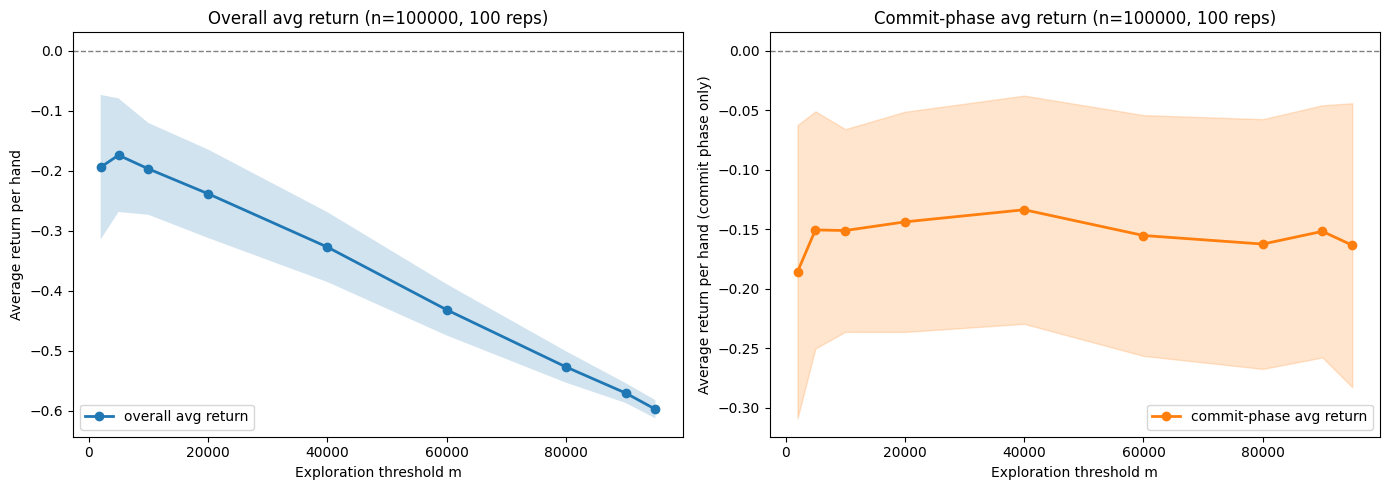

In [17]:
simulationETC(ETCAgentV3, agent_strategy=uniform_strategy, n=100000, m_values=[2000, 5000, 10000, 20000, 40000, 60000, 80000, 90000, 95000])

[ETC] Best response built over 222 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 192 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 192 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 210 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 246 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 189 info sets.
[ETC] Best response built over 222

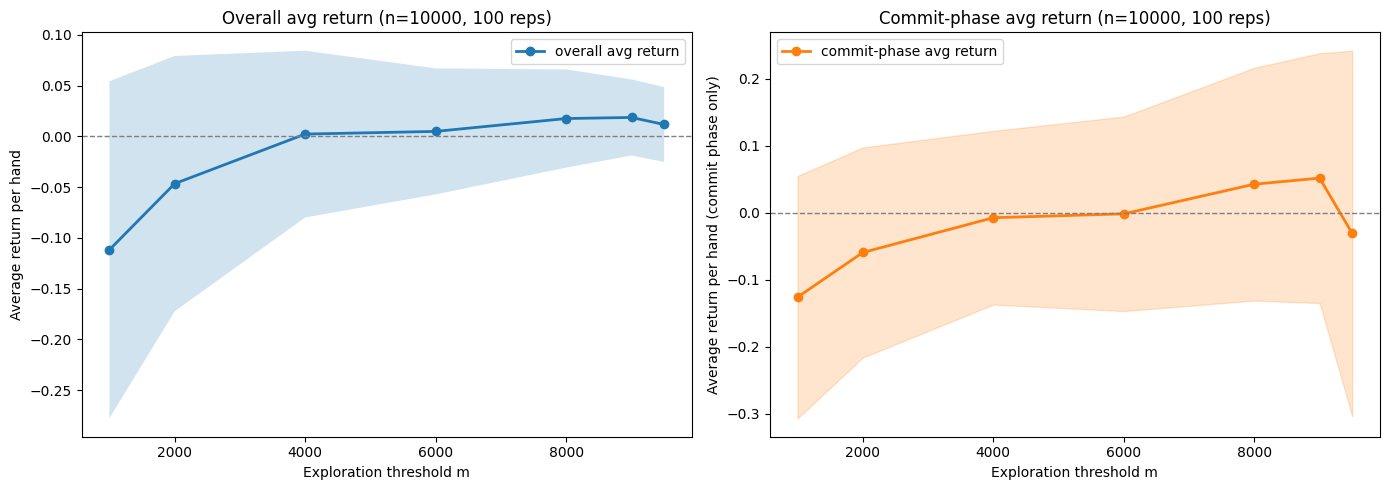

In [12]:
simulationETC(ETCAgentV4)

[ETC] Best response built over 225 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 195 info sets.
[ETC] Best response built over 207 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 189 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 213

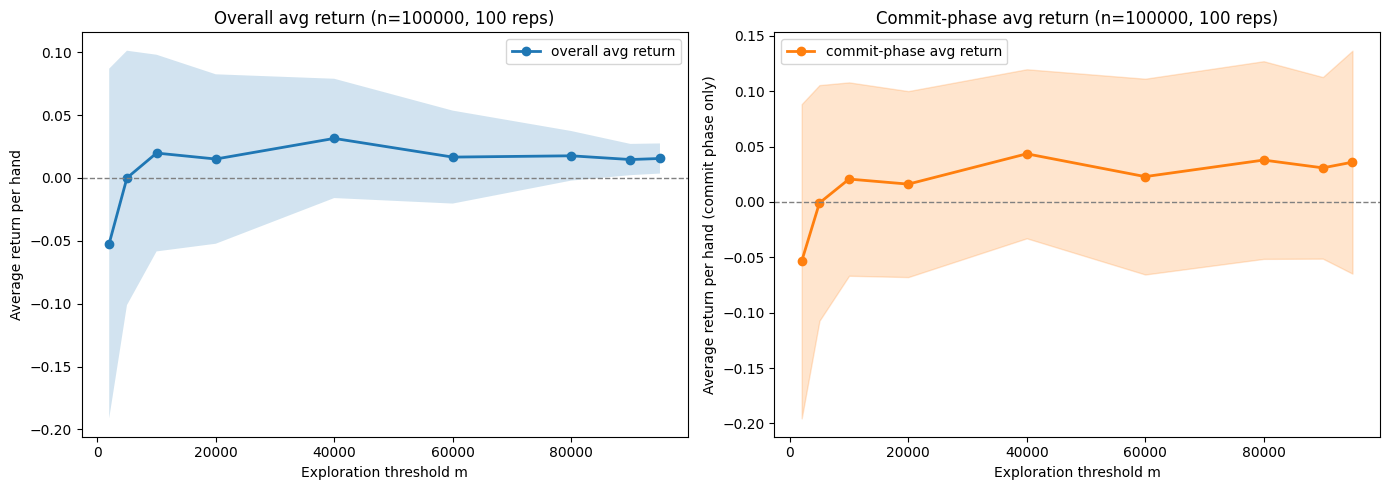

In [14]:
simulationETC(ETCAgentV4, n=100000, m_values=[2000, 5000, 10000, 20000, 40000, 60000, 80000, 90000, 95000])

[ETC] Best response built over 216 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 240 info sets.
[ETC] Best response built over 246 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 258 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 240 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 264 info sets.
[ETC] Best response built over 258 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 240 info sets.
[ETC] Best response built over 246 info sets.
[ETC] Best response built over 246 info sets.
[ETC] Best response built over 186

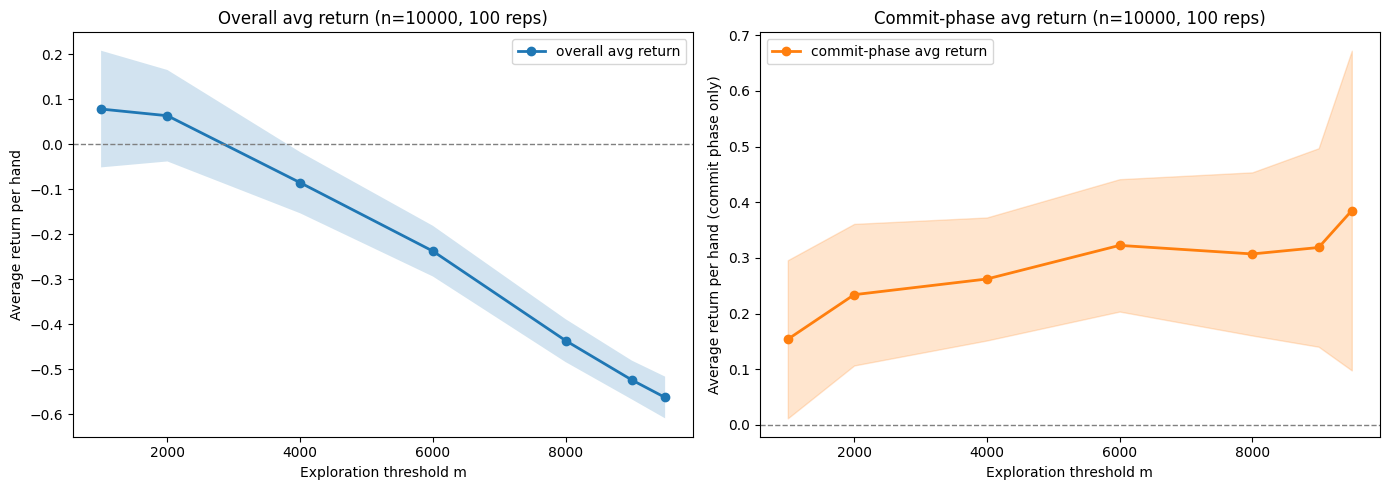

In [17]:
simulationETC(ETCAgentV4, agent_strategy=uniform_strategy)

[ETC] Best response built over 264 info sets.
[ETC] Best response built over 258 info sets.
[ETC] Best response built over 255 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 252 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 255 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 246 info sets.
[ETC] Best response built over 261 info sets.
[ETC] Best response built over 252 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 246 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 249 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 258 info sets.
[ETC] Best response built over 252

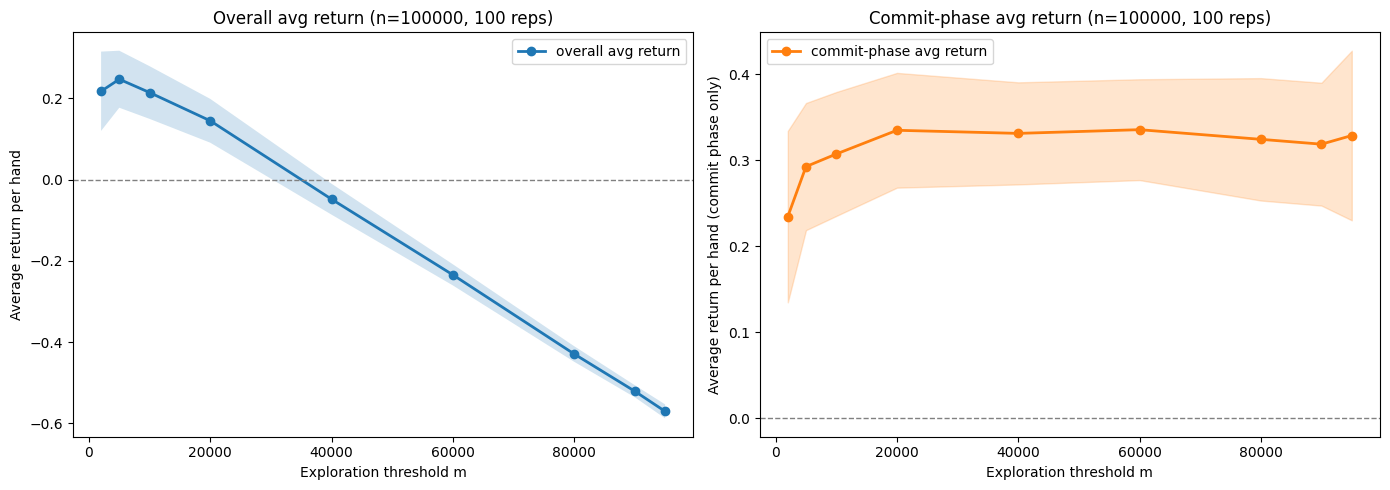

In [18]:
simulationETC(ETCAgentV4, agent_strategy=uniform_strategy, n=100000, m_values=[2000, 5000, 10000, 20000, 40000, 60000, 80000, 90000, 95000])